In [151]:
what_were_covering = {1: "data (prepare and load)",
                     2: "build model",
                     3: "fitting the model to data (training)",
                     4: "making predictions and evaluting a model (inference)",
                     5: "saving and loading model",
                     6: "putting it all together"}
what_were_covering

{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and evaluting a model (inference)',
 5: 'saving and loading model',
 6: 'putting it all together'}

In [152]:
import torch
from torch import nn  #nn contains all pytorch's building blocks for neural networks
import matplotlib.pyplot as plt
torch.__version__

'2.6.0'

## 1. Data (preparing and loading)

Machine learning is a game of two parts:

Get data into a numerical representation.
Build a model to learn patterns in that numerical representation.

In [153]:
#linear regression formula to make a straight line with known parameter.
#create known parameters:
weight = 0.7
bias = 0.3

#Create
X = torch.arange(0, 1, 0.02).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

## Splittind data into training and test sets

In [154]:
#Create a train/test split
train_size = int(0.8 * len(X))
train_size

40

In [155]:
X_train, y_train, X_test, y_test = X[:train_size], y[:train_size], X[train_size:], y[train_size:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

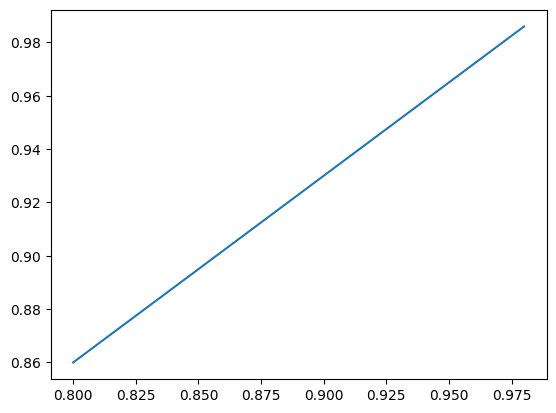

In [156]:
plt.plot(X_test, y_test)

## Visualize our data

In [157]:
def plot_predictions(train_data = X_train,
                    train_label = y_train,
                    test_data = X_test,
                    test_label = y_test,
                    predictions = None):

    #Plots training data, test data and compares predictions.
    plt.figure(figsize= (10,7)) #x ekseninin genişliği, y ekseninin genişliği

    #Plot traing data in green
    plt.scatter(train_data, train_label, c="g", s=4, label="Training Data")

    #Plot test data in blue
    plt.scatter(test_data, test_label, c="b", s=4, label="Test Data")

    #Plot the predictions if they exist
    if predictions is not None:
        plt.scatter(X_test, predictions, c="r", s=4, label="Predicitons")

    plt.legend(prop={"size": 12}) #label kutusunun büyüklüğünü ayarlar.
    

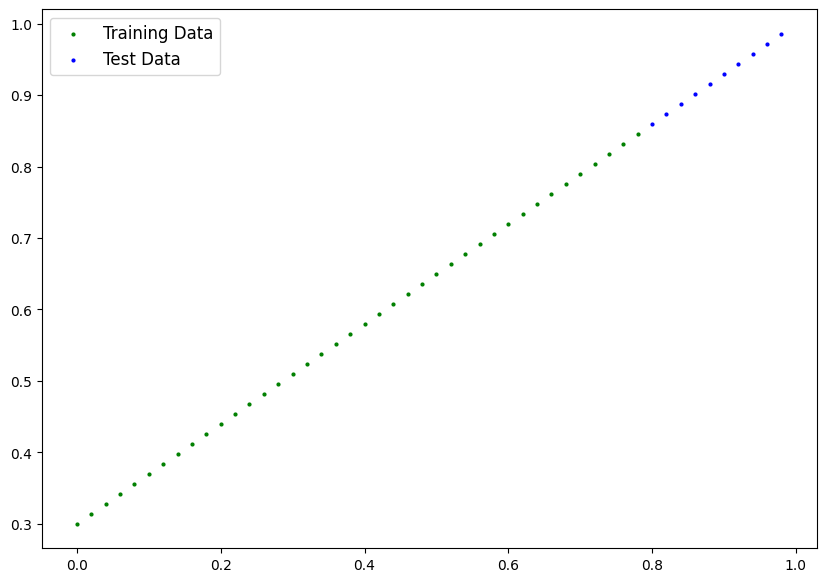

In [158]:
plot_predictions()

## 2. Build model

What our model does:
Start with random values (weight & bias)
Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight & bias values we used to create the data)

How does it do so?
Through two main algorithms:
1. Gradient descent
2. Backpropagation

In [159]:
# Create linear regression model class
class LinearRegressionModel(nn.Module):  # <- almost everything in PyTorch inherhits from nn.Module
    def __init__(self):
        super().__init__()  #üst sınıfın (nn.Module) başlangıç ayarlarını yapar.
        self.weights = nn.Parameter(torch.randn(1,  # <- start with a random weight and try to adjust it to the ideal weight
                                               requires_grad=True,  # <- can this parameter be updated via gradient descent?
                                               dtype=torch.float))  # <- PyTorch loves the datatype torch.float32
        
        self.bias = nn.Parameter(torch.randn(1,    # <- start with a random bias and try to adjust it to the ideal bias
                                            requires_grad=True,
                                            dtype=torch.float))

    # Forward method to define the computation in the model
    def forward(self, x:torch.tensor) -> torch.tensor:   # <- "x" is the input data
        return self.weights * x + self.bias              # this is the linear regression formula

## PyTorch model building essentials

torch.nn - contains all of the buildings for computational graphs (a neural network can be considered a computational graph)               
torch.nn.Parameter - what parameters should our model try and learn, often a PyTorch layer from torch.nn will set these for us             
torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwrite forward()                    
torch.optim - this where the optimizers in PyTorch live, they will help with gradient descent                              
def forward() - All nn.Module subclasses require you to overwrite forward(), this method defines what happens in the forward computation

In [160]:
#Create random seed
torch.manual_seed(42)

#Create an instance of the model (this is a subclass of nn.Module)
model_0 = LinearRegressionModel()

#checkout the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [161]:
#list named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

## Make predictions using torch.inference_mode()

In [162]:
#make predictions with model
with torch.inference_mode():  #Gradient takibini tamamen kapatır (autograd graph oluşturmaz).
    y_preds = model_0(X_test)

#We can also do something similar with torch.no_grad(), however, torch.inference_mode() is preferred
#with torch.no_grad():
#    y_preds = model_0(X_test)

y_preds, y_test

(tensor([[0.3982],
         [0.4049],
         [0.4116],
         [0.4184],
         [0.4251],
         [0.4318],
         [0.4386],
         [0.4453],
         [0.4520],
         [0.4588]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

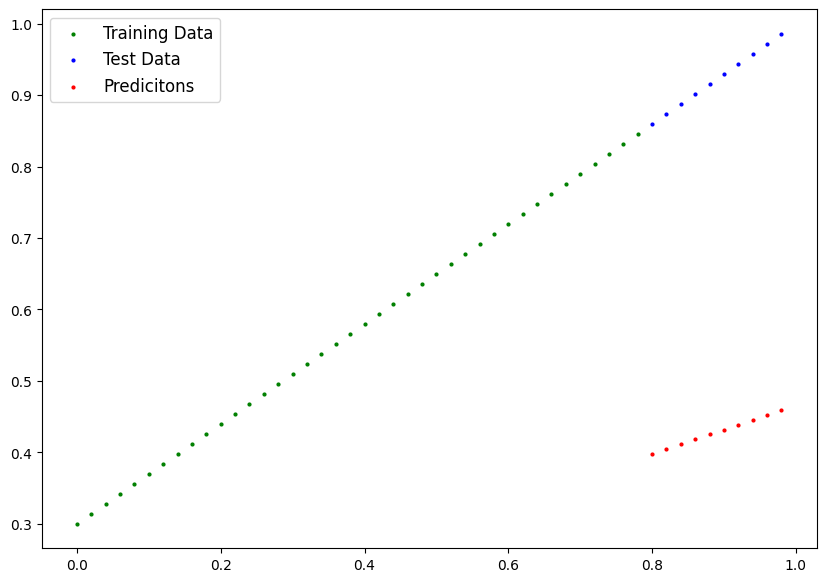

In [163]:
plot_predictions(predictions = y_preds)

## Train Model
Things we need to train:

Loss function: A function to measure how wrong your model's predictions are to the ideal outputs, lower is better.             
Optimizer: Takes into account the loss of a model and adjusts the model's parameters (e.g. weight & bias in our case) to improve the loss function                  

Inside the optimizer you'll often have to set two parameters:                    
params - the model parameters you'd like to optimize, for example params=model_0.parameters()                 
lr (learning rate) - the learning rate is a hyperparameter that defines how big/small the optimizer changes the parameters with each step (a small lr results in small changes, a large lr results in large changes)    

And specifically for PyTorch, we need:                 
A training loop            
A testing loop          

In [164]:
# Check out our model's parameters (a parameter is a value that the model sets itself)
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [165]:
#setup a loss function
loss_fn = nn.L1Loss()

#setup an optimizer (SGD)
optimizer = torch.optim.SGD(params = model_0.parameters(), #we want to optimize our the parameters present in our model
                           lr = 0.01)   #learning rate

## Building a training loop (and a testing loop) in PyTorch
A couple of things we need in a training loop: 

0. Loop through the data and do...
1. Forward pass (this involves data moving through our model's forward() functions) to make predictions on data - also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each of the parameters of our model with respect to the loss (**backpropagation**)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**gradient descent**)

In [166]:
# An epoch is one loop through the data... (this is a hyperparameter because we've set it ourselves)
epochs = 200

epoch_count = []
train_loss_values = []
test_loss_values = []

for epoch in range (epochs):
    
    # Set the model to training mode
    model_0.train()    # train mode in PyTorch sets all parameters that require gradients to require gradients 

    # 1. Forward pass
    y_pred = model_0(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, y_train)

    #In PyTorch, gradients accumulate (they are added up) by default. To start each new training step cleanly, you first zero out the old gradients.
    optimizer.zero_grad()

    #It computes the derivatives of the loss with respect to the model parameters (weights and bias). These gradients are stored in model_0.weights.grad and model_0.bias.grad.
    loss.backward()

    #The optimizer (e.g., SGD/Adam) looks at these gradients and updates w and b:
	#Simply: w = w - lr * w_grad
	#b = b - lr * b_grad
    optimizer.step()

    ### Testing
    model_0.eval()  # turns off different settings in the model not needed for evaluation/testing (dropout/batch norm layers)

    with torch.inference_mode():
        test_pred = model_0(X_test)                 # 1. Do the forward pass 
        test_loss = loss_fn(test_pred, y_test)      # 2. Calculate the loss
        
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        train_loss_values.append(loss)
        test_loss_values.append(test_loss)
        
        print(f"\nEpoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")
        print(model_0.state_dict())


Epoch: 0 | Loss: 0.31288135051727295 | Test Loss: 0.48106518387794495
OrderedDict([('weights', tensor([0.3406])), ('bias', tensor([0.1388]))])

Epoch: 10 | Loss: 0.1976713389158249 | Test Loss: 0.3463551998138428
OrderedDict([('weights', tensor([0.3796])), ('bias', tensor([0.2388]))])

Epoch: 20 | Loss: 0.08908725529909134 | Test Loss: 0.2172965705394745
OrderedDict([('weights', tensor([0.4184])), ('bias', tensor([0.3333]))])

Epoch: 30 | Loss: 0.053148530423641205 | Test Loss: 0.14464019238948822
OrderedDict([('weights', tensor([0.4512])), ('bias', tensor([0.3768]))])

Epoch: 40 | Loss: 0.04543796554207802 | Test Loss: 0.11360953748226166
OrderedDict([('weights', tensor([0.4748])), ('bias', tensor([0.3868]))])

Epoch: 50 | Loss: 0.04167863354086876 | Test Loss: 0.09919948130846024
OrderedDict([('weights', tensor([0.4938])), ('bias', tensor([0.3843]))])

Epoch: 60 | Loss: 0.03818932920694351 | Test Loss: 0.08886633813381195
OrderedDict([('weights', tensor([0.5116])), ('bias', tensor([

In [167]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

(None, None)

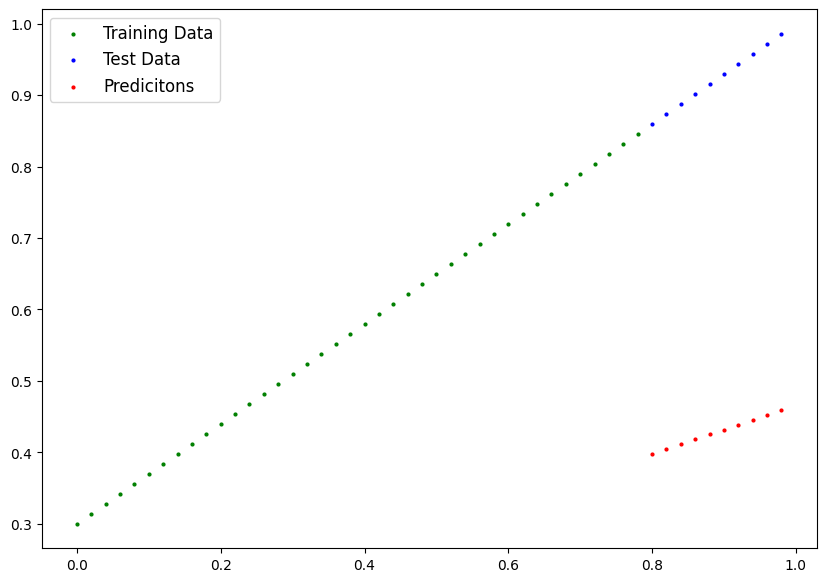

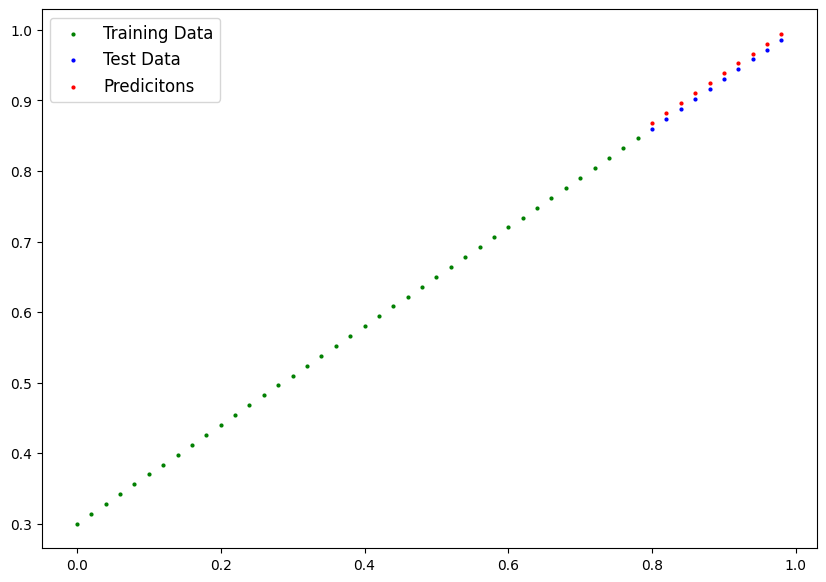

In [168]:
plot_predictions(predictions = y_preds) , plot_predictions(predictions = y_preds_new)

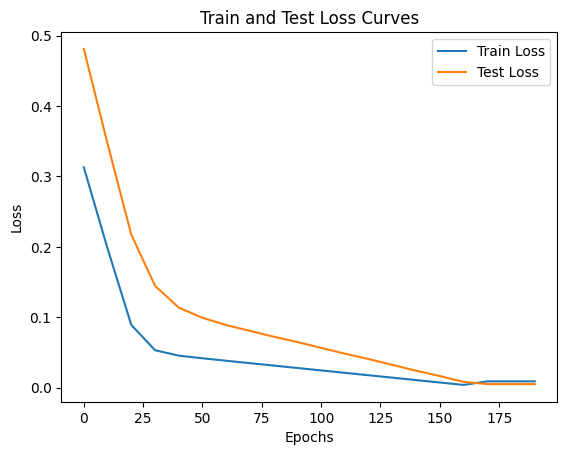

In [169]:
plt.plot(epoch_count, torch.tensor(train_loss_values).numpy(), label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.title("Train and Test Loss Curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

## Saving/Loading a model in PyTorch

There are three main methods you should about for saving and loading models in PyTorch.

**torch.save()** - allows you save a PyTorch object in Python's pickle format                    
**torch.load()** - allows you load a saved PyTorch object                
**torch.nn.Module.load_state_dict()** - this allows to load a model's saved state dictionary              

In [170]:
import os
os.makedirs("models", exist_ok=True)

#saving a pytorch model
MODEL_PATH = "models/01_pytorch_workflow_model_0.pth"
torch.save(model_0.state_dict(), MODEL_PATH)
print("Saved to ", MODEL_PATH)

Saved to  models/01_pytorch_workflow_model_0.pth


In [171]:
#Loading a pytorch model
loaded_model_0 = LinearRegressionModel()
loaded_model_0.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [172]:
#let's compare
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)

loaded_model_0.eval()
with torch.inference_mode():
    loaded_preds = loaded_model_0(X_test)

y_preds == loaded_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## Practice

In [173]:
#create data
w = 0.4
b = 0.23

X = torch.arange(1,101,5).unsqueeze(dim=1)
y = X * w + b
X, y

(tensor([[ 1],
         [ 6],
         [11],
         [16],
         [21],
         [26],
         [31],
         [36],
         [41],
         [46],
         [51],
         [56],
         [61],
         [66],
         [71],
         [76],
         [81],
         [86],
         [91],
         [96]]),
 tensor([[ 0.6300],
         [ 2.6300],
         [ 4.6300],
         [ 6.6300],
         [ 8.6300],
         [10.6300],
         [12.6300],
         [14.6300],
         [16.6300],
         [18.6300],
         [20.6300],
         [22.6300],
         [24.6300],
         [26.6300],
         [28.6300],
         [30.6300],
         [32.6300],
         [34.6300],
         [36.6300],
         [38.6300]]))

In [174]:
#split data
train_split = int(0.8 * len(X))
X_train, y_train, X_test, y_test = X[:train_split], y[:train_split], X[train_split:], y[train_split:]
X_train = X_train.float()
y_train = y_train.float()
X_test  = X_test.float()
y_test  = y_test.float()
len(X_train), len(y_train), len(X_test), len(y_test)


(16, 16, 4, 4)

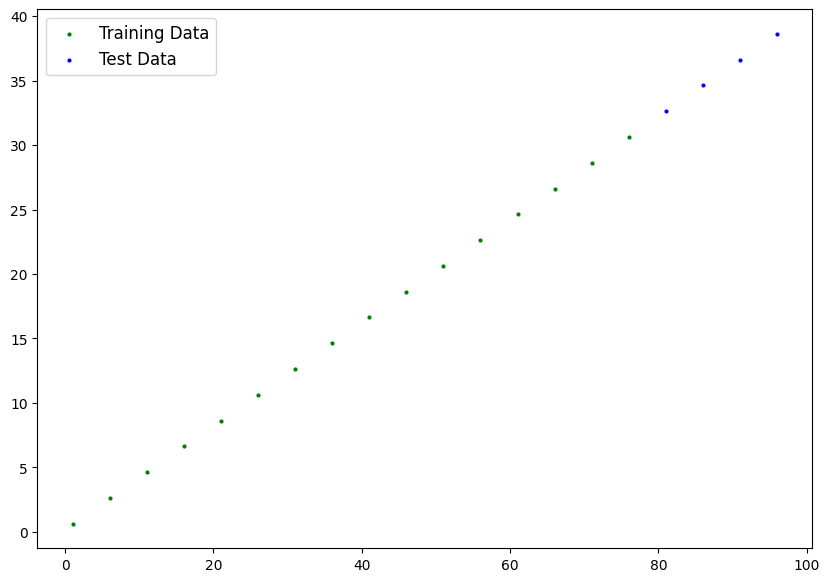

In [175]:
plot_predictions(X_train, y_train, X_test, y_test)

In [176]:
#buil linear regression model
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(in_features = 1,
                               out_features = 1)

    def forward(self, x):
        return self.linear(x)

model_1 = LinearRegressionModelV2()

In [177]:
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear.weight', tensor([[0.8815]])),
              ('linear.bias', tensor([-0.7336]))]))

In [178]:
def check_tensor(name, t):
    print(
        name,
        "| dtype:", t.dtype,
        "| shape:", tuple(t.shape),
        "| nan:", torch.isnan(t).any().item(),
        "| inf:", torch.isinf(t).any().item(),
        "| min:", t.min().item(),
        "| max:", t.max().item(),
    )

check_tensor("X_train", X_train)
check_tensor("y_train", y_train)
check_tensor("X_test", X_test)
check_tensor("y_test", y_test)

X_train | dtype: torch.float32 | shape: (16, 1) | nan: False | inf: False | min: 1.0 | max: 76.0
y_train | dtype: torch.float32 | shape: (16, 1) | nan: False | inf: False | min: 0.6299999952316284 | max: 30.6299991607666
X_test | dtype: torch.float32 | shape: (4, 1) | nan: False | inf: False | min: 81.0 | max: 96.0
y_test | dtype: torch.float32 | shape: (4, 1) | nan: False | inf: False | min: 32.630001068115234 | max: 38.630001068115234


In [179]:
#Training a model
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.0001)

epochs = 10
for epoch in range (epochs):
    model_1.train()
    y_preds = model_1(X_train)
    train_loss = loss_fn(y_preds, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    model_1.eval()
    with torch.inference_mode():
        test_preds = model_1(X_test)
        test_loss = loss_fn(test_preds, y_test)
    if epoch%20 == 0:
        print(f"Epoch: {epoch}, Train Loss: {train_loss}, Test Loss: {test_loss}")

Epoch: 0, Train Loss: 432.0960693359375, Test Loss: 634.9603881835938


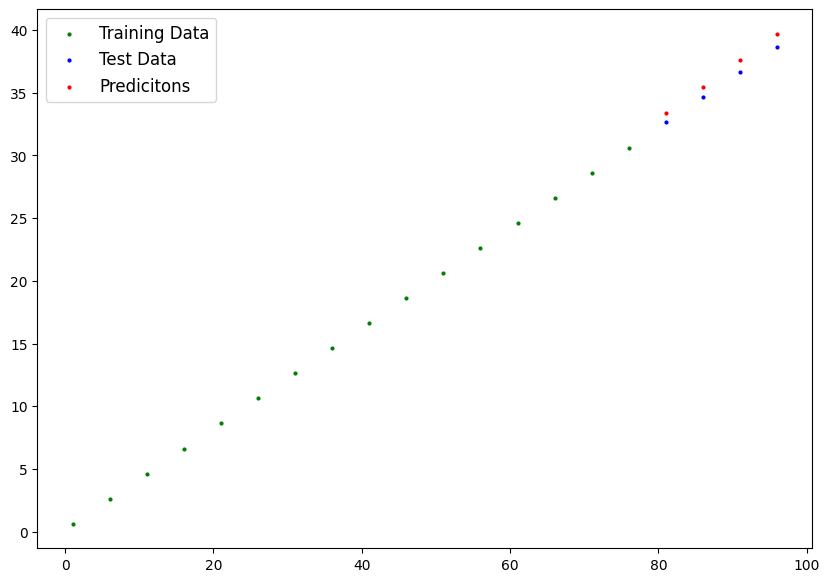

In [180]:
plot_predictions(X_train, y_train, X_test, y_test, test_preds)

In [183]:
#save model
PATH = "models/01_pytorch_workflow_model_1.pth"
torch.save(model_1.state_dict(), PATH)
print("Saved to: ", PATH)

#load model
loaded_model_1 = LinearRegressionModelV2()
loaded_model_1.load_state_dict(torch.load(PATH, map_location="cpu"))
loaded_model_1.eval()
print("Loaded and set to eval.")
loaded_model_1.state_dict(), model_1.state_dict()

Saved to:  models/01_pytorch_workflow_model_1.pth
Loaded and set to eval.


(OrderedDict([('linear.weight', tensor([[0.4213]])),
              ('linear.bias', tensor([-0.7419]))]),
 OrderedDict([('linear.weight', tensor([[0.4213]])),
              ('linear.bias', tensor([-0.7419]))]))